In [1]:
import sys
sys.path.append('../')

from spicy_snow.retrieval import retrieve_snow_depth
from spicy_snow.find_data import get_sentinel1_urls, find_snowcover_urls
from spicy_snow.utils.download import download_urls, download_urls_parallel
from spicy_snow.processing.generate_dataarrays import generate_sentinel1_dataarray, generate_snowcover_dataarray, generate_forest_fraction_dataarray, convert_snowcover_dates_to_s1_overpasses

import pandas as pd
from spicy_snow.utils.raster import combine_close_images, da_to01
from spicy_snow.utils.checks import validate_aoi, within_conus, validate_urls

import xarray as xr

In [2]:
test_start_date = '2020-10-01'
test_stop_date = '2021-05-01'
dates = [test_start_date, test_stop_date]
test_aoi = [-114.5, 43, -114, 44]

retrieval = retrieve_snow_depth(test_aoi, [test_start_date, test_stop_date], work_dir= '/Users/zmhoppinen/Documents/spicy-snow/local')

(spicy-snow spicy_snow.retrieval INFO) Downloading sentinel-1 gamma0 backscatter data
(spicy-snow asf_search INFO) SEARCH: Using search opts {
    "intersectsWith": "POLYGON ((-114.0000000000000000 43.0000000000000000, -114.0000000000000000 44.0000000000000000, -114.5000000000000000 44.0000000000000000, -114.5000000000000000 43.0000000000000000, -114.0000000000000000 43.0000000000000000))",
    "platform": [
        "SENTINEL-1A",
        "SENTINEL-1C",
        "SENTINEL-1B"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-10-01T00:00:00Z",
    "end": "2021-05-01T00:00:00Z"
}
(spicy-snow asf_search INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow asf_search INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POLYGON ((-114.0000000000000000 43.0000000000000000, -114.0000000000000000 44.0000000000000000, -114.5000000000000000 44.0000000000000000, -114.5000000000000000 43.0000000000000000, -

Downloading:   0%|          | 0/2022 [00:00<?, ?it/s]

Reprojecting + inserting vv:   0%|          | 0/674 [00:00<?, ?it/s]

/Users/zmhoppinen/miniforge3/envs/spicy_testing/lib/python3.13/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


Reprojecting + inserting vh:   0%|          | 0/674 [00:00<?, ?it/s]

(spicy-snow spicy_snow.retrieval INFO) Downloading VIIRS snowcover data
(spicy-snow earthaccess.auth INFO) You're now authenticated with NASA Earthdata Login
(spicy-snow earthaccess.api INFO) Granules found: 213


Downloading:   0%|          | 0/86 [00:00<?, ?it/s]

(spicy-snow spicy_snow.retrieval INFO) Downloading forest cover fraction data
(spicy-snow spicy_snow.processing.generate_dataarrays INFO) AOI inside of CONUS. NLCD 2021 Forest Cover
(spicy-snow spicy_snow.retrieval INFO) Preprocessing Sentinel-1 images
(spicy-snow spicy_snow.retrieval INFO) Calculating snow index
(spicy-snow spicy_snow.retrieval INFO) Flag wet snow


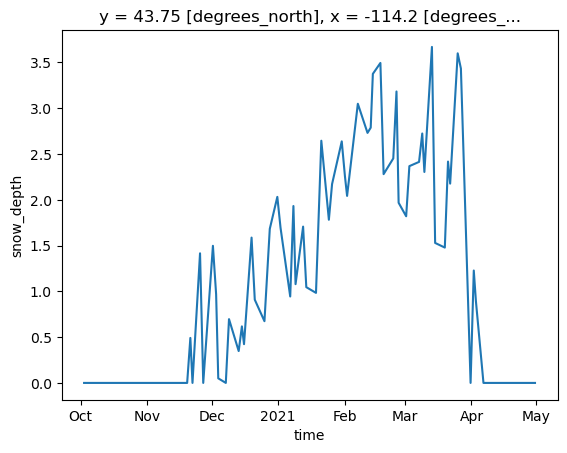

In [3]:
retrieval.sel(x = -114.2, y = 43.75, method = 'nearest')['snow_depth'].plot()

In [4]:
test_start_date = '2020-10-01'
test_stop_date = '2021-05-01'
dates = [test_start_date, test_stop_date]
test_aoi = [-114.2, 43.75]

point_retrieval = retrieve_snow_depth(test_aoi, [test_start_date, test_stop_date], work_dir= '/Users/zmhoppinen/Documents/spicy-snow/local')

(spicy-snow spicy_snow.retrieval INFO) Downloading sentinel-1 gamma0 backscatter data
(spicy-snow asf_search INFO) SEARCH: Using search opts {
    "intersectsWith": "POINT (-114.2000000000000028 43.7500000000000000)",
    "platform": [
        "SENTINEL-1A",
        "SENTINEL-1C",
        "SENTINEL-1B"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-10-01T00:00:00Z",
    "end": "2021-05-01T00:00:00Z"
}
(spicy-snow asf_search INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow asf_search INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POINT (-114.2000000000000028 43.7500000000000000)",
    "start": "2020-10-01T00:00:00Z",
    "end": "2021-05-01T00:00:00Z",
    "collections": [
        "C1259974840-ASF",
        "C1260721853-ASF",
        "C2777436413-ASF",
        "C2803501097-ASF"
    ]
}
(spicy-snow asf_search INFO) Query Time Elapsed 0.7370333671569824
(spicy-snow asf_search INFO) Pag

Downloading:   0%|          | 0/258 [00:00<?, ?it/s]

Reprojecting + inserting vv:   0%|          | 0/86 [00:00<?, ?it/s]

Reprojecting + inserting vh:   0%|          | 0/86 [00:00<?, ?it/s]

(spicy-snow spicy_snow.retrieval INFO) Downloading VIIRS snowcover data
(spicy-snow earthaccess.api INFO) Granules found: 213


Downloading:   0%|          | 0/86 [00:00<?, ?it/s]

(spicy-snow spicy_snow.retrieval INFO) Downloading forest cover fraction data
(spicy-snow spicy_snow.processing.generate_dataarrays INFO) AOI inside of CONUS. NLCD 2021 Forest Cover
(spicy-snow spicy_snow.retrieval INFO) Preprocessing Sentinel-1 images
(spicy-snow spicy_snow.retrieval INFO) Calculating snow index
(spicy-snow spicy_snow.retrieval INFO) Flag wet snow


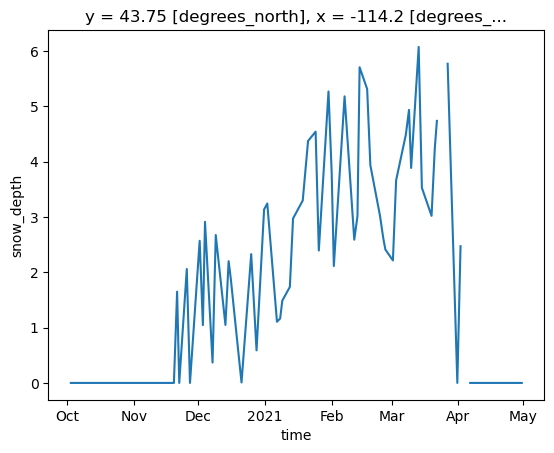

In [5]:
point_retrieval['snow_depth'].plot()

In [6]:
test_start_date = '2020-10-01'
test_stop_date = '2021-04-01'
dates = [test_start_date, test_stop_date]
test_aoi = [-114.5, 43, -114, 44]
aoi = test_aoi
ref = None

In [7]:
import asyncio
from pathlib import Path
import aiohttp
from tqdm.asyncio import tqdm_asyncio
import random

async def download_urls_async(
    urls,
    out_directory,
    max_concurrent=32,
    retries=5,
    timeout=30,
    backoff_429=5,
):
    """
    Asynchronously download URLs with retries and exponential backoff for 429s.
    Writes files to disk immediately.
    """

    urls = list(urls)
    out_directory = Path(out_directory)
    out_directory.mkdir(parents=True, exist_ok=True)

    semaphore = asyncio.Semaphore(max_concurrent)
    downloaded_files = []

    async def fetch(url):
        out_fp = out_directory / Path(url).name

        if out_fp.exists() and out_fp.stat().st_size != 0:
            return out_fp

        for attempt in range(retries):
            try:
                async with semaphore:
                    timeout_ctx = aiohttp.ClientTimeout(total=timeout)
                    async with aiohttp.ClientSession(timeout=timeout_ctx) as session:
                        async with session.get(url) as resp:
                            if resp.status == 429:
                                raise aiohttp.ClientResponseError(
                                    resp.request_info,
                                    resp.history,
                                    status=429,
                                    message="Too Many Requests",
                                    headers=resp.headers,
                                )
                            resp.raise_for_status()
                            with open(out_fp, "wb") as f:
                                async for chunk in resp.content.iter_chunked(256*1024):
                                    f.write(chunk)
                return out_fp

            except aiohttp.ClientResponseError as e:
                if e.status == 429:
                    wait = backoff_429 * (2 ** attempt) + random.uniform(0, 2)
                    await asyncio.sleep(wait)
                else:
                    if attempt == retries - 1:
                        raise
                    await asyncio.sleep(1.5)
            except Exception:
                if attempt == retries - 1:
                    raise
                await asyncio.sleep(1.5)

        return out_fp

    tasks = [fetch(url) for url in urls]

    for fut in tqdm_asyncio.as_completed(tasks, total=len(urls), desc="Downloading"):
        downloaded_files.append(await fut)

    return downloaded_files


In [8]:
import numpy as np
import pandas as pd
import xarray as xr

from spicy_snow.processing.generate_dataarrays import combine_close_images, generate_sentinel1_dataarray
from spicy_snow.find_data import get_sentinel1_urls, find_snowcover_urls
from spicy_snow.utils.download import download_urls, download_urls_parallel
from spicy_snow.utils.checks import validate_aoi


from pathlib import Path
work_dir = Path('/Users/zmhoppinen/Documents/spicy-snow/local')
# get sentinel 1 data search results
s1_urls = get_sentinel1_urls(start_date = dates[0], stop_date = dates[1], aoi = aoi)
s1_urls = [u for u in s1_urls if u.endswith(('_VV.tif', '_VH.tif', '_mask.tif'))]

# import nest_asyncio
# nest_asyncio.apply()

# import asyncio
s1_fps = await download_urls_async(
    s1_urls,
    out_directory=work_dir.joinpath("opera"),
    max_concurrent=128,
    retries=5,
    timeout=30,
    backoff_429=20
)

# s1_fps = await download_urls_async(
#     s1_urls,
#     out_directory=work_dir.joinpath('opera'),
#     max_concurrent=128,
#     retries=5,
#     timeout=30,
#     backoff_429=20
# )

# s1_fps = download_urls_parallel(s1_urls, work_dir.joinpath('opera'))
# import nest_asyncio
# nest_asyncio.apply()

# import asyncio

# s1_fps = await download_urls_async(
#     s1_urls, 
#     out_directory=work_dir.joinpath('opera'),
#     max_concurrent=128,
#     retries=5,
#     timeout=30
# )

# s1_fps = asyncio.run(download_urls_async(s1_urls, work_dir.joinpath('opera'), max_concurrent=128))
# vv = generate_sentinel1_dataarray(s1_fps, aoi, 'vv') #, '/Users/zmhoppinen/Documents/spicy-snow/local/test.zarr')

(spicy-snow asf_search INFO) SEARCH: Using search opts {
    "intersectsWith": "POLYGON ((-114.0000000000000000 43.0000000000000000, -114.0000000000000000 44.0000000000000000, -114.5000000000000000 44.0000000000000000, -114.5000000000000000 43.0000000000000000, -114.0000000000000000 43.0000000000000000))",
    "platform": [
        "SENTINEL-1A",
        "SENTINEL-1C",
        "SENTINEL-1B"
    ],
    "processingLevel": [
        "RTC"
    ],
    "start": "2020-10-01T00:00:00Z",
    "end": "2021-04-01T00:00:00Z"
}
(spicy-snow asf_search INFO) SEARCH: Using cmr endpoint: "https://cmr.earthdata.nasa.gov/search/granules.umm_json"
(spicy-snow asf_search INFO) SUBQUERY 1: Beginning subquery with opts: {
    "intersectsWith": "POLYGON ((-114.0000000000000000 43.0000000000000000, -114.0000000000000000 44.0000000000000000, -114.5000000000000000 44.0000000000000000, -114.5000000000000000 43.0000000000000000, -114.0000000000000000 43.0000000000000000))",
    "start": "2020-10-01T00:00:00Z",
    

Downloading: 100%|██████████| 1713/1713 [00:00<00:00, 92008.38it/s]


In [9]:

def preallocate_output(ref_da, times, zarr_path = None):
    y = ref_da["y"]
    x = ref_da["x"]

    data = np.zeros(
        (len(times), len(y), len(x)),
        dtype=ref_da.dtype,
    )

    da = xr.DataArray(
        data,
        dims=("time", "y", "x"),
        coords={
            "time": times,
            "y": y,
            "x": x,
        }
    )
    
    # save spatial reference information
    da = da.rio.write_crs(ref_da.rio.crs)
    da = da.rio.write_transform(ref_da.rio.transform())

    if zarr_path is not None:
        zarr_path = Path(zarr_path)
        da.to_zarr(zarr_path, mode="w")

    return da



def generate_sentinel1_dataarray(s1_fps, aoi, pol, zarr_path = None, ref = None, resolution=(100, 100)):
    aoi = validate_aoi(aoi)
    pol = pol.lower()

    times = []
    tracks = []

    pol_fps = [f for f in s1_fps if f.stem.lower().endswith(pol)]

    # First pass — collect timestamps
    for fp in pol_fps:
        if fp.stem.lower().endswith(pol):
            t = pd.to_datetime(fp.stem.split('_')[4], format='%Y%m%dT%H%M%SZ')
            times.append(t)

            track = int(fp.stem.split('_')[3].split('-')[0][1:])
            tracks.append(track)

    # Build reference grid from first file
    if ref is None:
        ref = xr.open_dataarray(pol_fps[0], chunks="auto")[0]
        assert ref.rio.crs.is_projected, f'Unable to set spatial resolution with non-projected crs: {ref.rio.crs}'

        ref = ref.rio.reproject(dst_crs=ref.rio.crs, resolution=resolution)
        ref = ref.rio.reproject("EPSG:4326")
        ref = ref.rio.clip_box(*aoi.bounds).rio.pad_box(*aoi.bounds)

    # Create empty on-disk dataset
    zarr = preallocate_output(
        ref,
        times,
        zarr_path=zarr_path
    )

    zarr = zarr.assign_coords(track = ("time", tracks))

    # # Write slices one-by-one
    # for fp, time in tqdm(zip(pol_fps, times, strict = True), desc=f"Merging s1 tifs for {pol}", total = len(times)):
    #     img = xr.open_dataarray(fp, chunks="auto")[0]

    #     mask_fp = fp.parent.joinpath(f'{fp.stem[:-3]}_mask.tif')
    #     if mask_fp.exists():
    #         mask = xr.open_dataarray(mask_fp)[0]
    #         # section 4.3 https://d2pn8kiwq2w21t.cloudfront.net/documents/ProductSpec_RTC-S1.pdf
    #         # 0 = not affected by layover or shadow
    #         mask = mask == 0
    #         img = img.where(mask)

    #     img = img.rio.reproject_match(ref)
    #     zarr.loc[dict(time = time)] = img
    var = zarr.data  # or zarr.data for DataArray
    # var = root[ref.name]  # typically ref.name

    for i, (fp, time) in enumerate(zip(pol_fps, times)):
        img = xr.open_dataarray(fp, chunks=None)[0]  # no Dask chunks

        mask_fp = fp.parent / f'{fp.stem[:-3]}_mask.tif'
        if mask_fp.exists():
            mask = xr.open_dataarray(mask_fp, chunks=None)[0] == 0
            img = img.where(mask)

        img = img.rio.reproject_match(ref).load()  # load now, release after write

        var[i, :, :] = img.values  # direct Zarr write

        del img
        import gc
        gc.collect()
    
    zarr = combine_close_images(zarr.sortby('time'))

    # Re-open final dataset (lazy)
    if zarr_path is not None:
        zarr = xr.open_zarr(zarr_path)

    return zarr


In [10]:
import numpy as np
import xarray as xr
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.enums import Resampling as Rsmp
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm


def generate_sentinel1_dataarray(
    s1_fps,
    aoi,
    pol,
    zarr_path=None,
    ref=None,
    resolution=(100, 100),
    max_workers=8,
):

    aoi = validate_aoi(aoi)
    pol = pol.lower()

    # Filter relevant products
    pol_fps = [f for f in s1_fps if f.stem.lower().endswith(pol)]

    # Extract timestamps + tracks
    times = []
    tracks = []
    for fp in pol_fps:
        t = pd.to_datetime(fp.stem.split('_')[4], format='%Y%m%dT%H%M%SZ')
        times.append(t)

        track = int(fp.stem.split('_')[3].split('-')[0][1:])
        tracks.append(track)

    # ---- Build reference grid ----
    if ref is None:
        ref = xr.open_dataarray(pol_fps[0], chunks="auto")[0]
        assert ref.rio.crs.is_projected
        ref = ref.rio.reproject(dst_crs=ref.rio.crs, resolution=resolution)
        ref = ref.rio.reproject("EPSG:4326")
        ref = ref.rio.clip_box(*aoi.bounds).rio.pad_box(*aoi.bounds)

    dst_crs = ref.rio.crs
    dst_transform = ref.rio.transform()
    dst_shape = ref.shape  # (y, x)

    # ---- Preallocate Zarr-backed DataArray ----
    zarr = preallocate_output(ref, times, zarr_path=zarr_path)
    zarr = zarr.assign_coords(track=("time", tracks))

    # Direct access to Zarr array (no .loc)
    z = zarr.data

    def process_one(args):
        fp, idx = args

        with rasterio.open(fp) as src:
            img = src.read(1).astype("float32")

            mask_fp = fp.parent / f"{fp.stem[:-3]}_mask.tif"
            if mask_fp.exists():
                with rasterio.open(mask_fp) as m:
                    mask = (m.read(1) == 0)
                img = np.where(mask, img, np.nan)

            # initialize with NaNs, not zeros
            dst = np.full(dst_shape, np.nan, dtype="float32")

            reproject(
                img,
                dst,
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=dst_transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear,
                src_nodata=0,
                dst_nodata=np.nan,
            )

        return idx, dst

    # ---- Parallel projection + writing ----
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        for idx, dst in tqdm(
            ex.map(process_one, [(fp, i) for i, fp in enumerate(pol_fps)]),
            total=len(pol_fps),
            desc=f"Reprojecting + inserting {pol}",
        ):
            z[idx, :, :] = dst  # FAST direct Zarr write

    # Optionally collapse near-duplicate timesteps
    out = combine_close_images(zarr.sortby("time"))

    if zarr_path is not None:
        out = xr.open_zarr(zarr_path)

    return out


In [11]:
vv = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'vv')

Reprojecting + inserting vv:   0%|          | 0/571 [00:00<?, ?it/s]

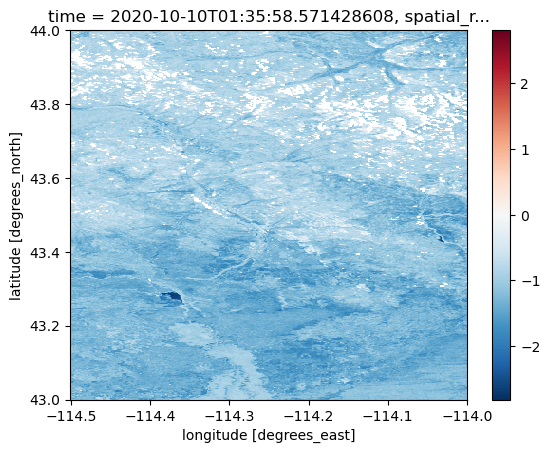

In [12]:
np.log10(vv[4]).plot()

In [13]:
import time
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
import requests


def download_urls_parallel(
    urls,
    out_directory,
    reprocess=False,
    retries=3,
    max_workers=10,
    timeout=20,
):
    """
    Faster parallel downloader using a shared requests.Session,
    keep-alive, connection pooling, larger thread pool,
    and streaming writes.
    """

    urls = validate_urls(urls)
    out_directory = Path(out_directory)
    out_directory.mkdir(parents=True, exist_ok=True)

    # --- KEY SPEED-UP: pooled TCP connections
    session = requests.Session()
    adapter = requests.adapters.HTTPAdapter(pool_connections=max_workers,
                                            pool_maxsize=max_workers,
                                            max_retries=0)
    session.mount("https://", adapter)
    session.mount("http://", adapter)

    def download_one(url):
        out_fp = out_directory / Path(url).name

        if out_fp.exists() and out_fp.stat().st_size != 0 and not reprocess:
            return out_fp

        for attempt in range(retries):
            try:
                r = session.get(url, stream=True, timeout=timeout)
                r.raise_for_status()

                # Fast streaming write
                with open(out_fp, "wb") as f:
                    for chunk in r.iter_content(chunk_size=256 * 1024):
                        if chunk:
                            f.write(chunk)
                return out_fp

            except Exception:
                if attempt == retries - 1:
                    raise
                time.sleep(1.5)

        return out_fp

    # multi-threaded dispatch
    download_fps = []
    with ThreadPoolExecutor(max_workers=max_workers) as ex:
        futures = {ex.submit(download_one, url): url for url in urls}
        for fut in tqdm(as_completed(futures), total=len(urls), desc="Downloading"):
            download_fps.append(fut.result())

    return download_fps


In [14]:
download_urls_parallel(s1_urls, '/Users/zmhoppinen/Documents/spicy-snow/local/opera')

Downloading:   0%|          | 0/1713 [00:00<?, ?it/s]

[PosixPath('/Users/zmhoppinen/Documents/spicy-snow/local/opera/OPERA_L2_RTC-S1_T071-151170-IW1_20210325T134918Z_20250904T125113Z_S1B_30_v1.0_mask.tif'),
 PosixPath('/Users/zmhoppinen/Documents/spicy-snow/local/opera/OPERA_L2_RTC-S1_T093-197867-IW3_20210309T013645Z_20250904T195012Z_S1A_30_v1.0_VH.tif'),
 PosixPath('/Users/zmhoppinen/Documents/spicy-snow/local/opera/OPERA_L2_RTC-S1_T071-151172-IW1_20210319T135006Z_20250904T150249Z_S1A_30_v1.0_mask.tif'),
 PosixPath('/Users/zmhoppinen/Documents/spicy-snow/local/opera/OPERA_L2_RTC-S1_T093-197867-IW3_20210327T013603Z_20250904T114844Z_S1B_30_v1.0_VV.tif'),
 PosixPath('/Users/zmhoppinen/Documents/spicy-snow/local/opera/OPERA_L2_RTC-S1_T071-151168-IW1_20210325T134913Z_20250904T125113Z_S1B_30_v1.0_VV.tif'),
 PosixPath('/Users/zmhoppinen/Documents/spicy-snow/local/opera/OPERA_L2_RTC-S1_T020-041066-IW1_20210322T012741Z_20250904T135740Z_S1B_30_v1.0_mask.tif'),
 PosixPath('/Users/zmhoppinen/Documents/spicy-snow/local/opera/OPERA_L2_RTC-S1_T071-1511

In [15]:
import numpy as np
import pandas as pd
import xarray as xr
first_fp = s1_fps[0]
resolution = (100, 100)
pol = 'vv'

In [16]:
times = []
tracks = []
# First pass — collect timestamps
pol_fps = [f for f in s1_fps if f.stem.lower().endswith(pol)]
for fp in pol_fps:
    if fp.stem.lower().endswith(pol):
        t = pd.to_datetime(fp.stem.split('_')[4], format='%Y%m%dT%H%M%SZ')
        times.append(t)

        track = int(fp.stem.split('_')[3].split('-')[0][1:])
        tracks.append(track)

from shapely.geometry import box
# Build reference grid from first file
if ref is None:
    first_fp = s1_fps[0]
    ref = xr.open_dataarray(first_fp, chunks="auto")[0]
    assert ref.rio.crs.is_projected, f'Unable to set spatial resolution with non-projected crs: {ref.rio.crs}'

    ref = ref.rio.reproject(dst_crs=ref.rio.crs, resolution=resolution)
    ref = ref.rio.reproject("EPSG:4326")
    ref = ref.rio.clip_box(*box(*aoi).bounds).rio.pad_box(*box(*aoi).bounds)


In [17]:
ref.rio.write_

AttributeError: 'RasterArray' object has no attribute 'write_'

In [ ]:
zarr_path = '/Users/zmhoppinen/Documents/spicy-snow/local/simple.zarr'
path = Path(zarr_path)

y = ref["y"]
x = ref["x"]

data = np.zeros(
    (len(times), len(y), len(x)),
    dtype=ref.dtype,
)

da = xr.DataArray(
    data,  # the actual array: shape (time, y, x)
    dims=("time", "y", "x"),
    coords={
        "time": times,
        "y": y,
        "x": x,
        "track": ("time", tracks),
        # "platform": ("time", platforms),  # optional
    },
    name=pol,  # name of the variable
)

da.to_zarr(path, mode="w")

In [ ]:
from tqdm import tqdm
# Write slices one-by-one
for fp, time in tqdm(zip(pol_fps, times, strict = True), desc=f"Merging s1 tifs for {pol}", total = len(times)):
    img = xr.open_dataarray(fp, chunks="auto")[0]
    img = img.rio.reproject_match(ref)
    da.loc[dict(time = time)] = img


In [ ]:
da

In [ ]:
combine_close_images(da)

In [ ]:
da.loc[dict(time = '2020-02-23T13:49:15')] = ref

In [ ]:
da.sel(time = '2020-02-23T13:49:15').plot()

In [ ]:
import numpy as np
# combine_close_images(vv)[1].plot()
vv[2].plot()

In [ ]:
import dask
import numpy as np
test = dask.array.zeros((10, 100, 100), chunks = 'auto', dtype = np.float32)
test_da = xr.DataArray(test, dims = ("time", 'y', 'x'))
test_da.to_zarr('/Users/zmhoppinen/Documents/spicy-snow/local/simple.zarr', mode="w")
img = xr.DataArray(np.random.random((100, 100)), dims = ['y', 'x'])
test_da[0, :, :] = img
np.array(test_da[0, :, :])

In [ ]:
fasdlkjfsa

In [ ]:
retrieval = retrieve_snow_depth(test_aoi, [test_start_date, test_stop_date], work_dir= '/Users/zmhoppinen/Documents/spicy-snow/local')

In [ ]:
pol = 'vv'
chunks = 'auto'
ref = None
spatial_resolution = (100, 100)
aoi = validate_aoi(aoi)
da_list = []
times = []

from tqdm import tqdm
for fp in tqdm(s1_fps, desc = 'Merging datasets'):
    if fp.stem.lower().endswith(pol):
            time = pd.to_datetime(fp.stem.split('_')[4], format = '%Y%m%dT%H%M%SZ')
            track = int(fp.stem.split('_')[3].split('-')[0][1:])
            satellite_number = fp.stem.split('_')[6]
            mask_fp = fp.parent.joinpath(f'{fp.stem[:-3]}_mask.tif')
            if mask_fp.exists():
                mask = xr.open_dataarray(mask_fp, chunks=chunks)[0]
                # section 4.3 https://d2pn8kiwq2w21t.cloudfront.net/documents/ProductSpec_RTC-S1.pdf
                # 0 = not affected by layover or shadow
                mask = mask.where(mask == 0)
            
            da = xr.open_dataarray(fp, chunks = chunks)[0]
            if ref is None:
                assert da.rio.crs.is_projected, f'Unable to set spatial resolution with non-projected crs: {da.rio.crs}'
                ref = da.rio.reproject(dst_crs = da.rio.crs, resolution=spatial_resolution)
                ref = ref.rio.reproject('EPSG:4326')
                ref = ref.rio.clip_box(*aoi.bounds)
                ref = ref.rio.pad_box(*aoi.bounds)
            else:
                da = da.rio.reproject_match(ref)

            da = da.expand_dims(time = [time])
            # add relative orbit information
            da = da.assign_coords(track = ('time', [track]))
            # add satellite information
            da = da.assign_coords(platform = ('time', [satellite_number]))

            da_list.append(da)
            times.append(time)

y = ref["y"]
x = ref["x"]

# Dask array placeholder
data = da.zeros(
    (len(da_list), len(y), len(x)), 
    chunks=(1, "auto", "auto"),
    dtype=ref.dtype)

ds = xr.Dataset(
    {pol: (("time", "y", "x"), data)},
    coords=dict(
        time=("time", times),
        y=y,
        x=x,))

# concatenate along time dimension
stacked = xr.concat(da_list, dim='time').sortby('time')

# next stack close times spatially
stacked = combine_close_images(stacked)
stacked.name = pol


In [ ]:
# generate dataset and start to save s1 data vars
ds = xr.Dataset()
ds['vv'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VV')

# grab spatial reference from first time step of VV
spatial_reference = ds['vv'].isel(time =0)

ds['vh'] = generate_sentinel1_dataarray(s1_fps, aoi, pol = 'VH', ref = spatial_reference)

# download viirs snow cover fraction for each sentinel 1 overpass date
snowcover_urls = find_snowcover_urls(date_list = ds.time.dt.date, aoi = aoi)
snowcover_fps = download_urls(snowcover_urls, work_dir.joinpath('snowcover'))

# generate snow cover dataset
viirs_snowcover = generate_snowcover_dataarray(snowcover_fps, ref = spatial_reference)

# resample date times from each day to the exact s1 overpass time. Doubles if two in one day
viirs_snowcover = convert_snowcover_dates_to_s1_overpasses(viirs_snowcover, ds['vv'])


In [ ]:
snowcover_urls = find_snowcover_urls(date_list = ds.time.dt.date, aoi = test_aoi)
snowcover_fps = download_urls(snowcover_urls, '/Users/zmhoppinen/Documents/spicy-snow/local/snowcover')
viirs_snowcover = generate_snowcover_dataarray(snowcover_fps, ref = spatial_reference)
viirs_snowcover = convert_snowcover_dates_to_s1_overpasses(viirs_snowcover, ds['vv'])
# table 1 https://nsidc.org/sites/default/files/documents/user-guide/multi_vnp10a1f-v002-userguide.pdf
ds['watermask'] = (viirs_snowcover == 237).median('time')
ds['snowcover'] = viirs_snowcover.where(viirs_snowcover <= 100) > 10

In [ ]:
ds['snowcover']

In [ ]:
ds['fcf'] = generate_forest_fraction_dataarray(test_aoi, ref = spatial_reference)

In [ ]:
ds['watermask'].median('time').plot()

In [ ]:
ds['vv'].where(~ds['watermask'])[0].plot()